<a href="https://colab.research.google.com/github/Chen-M-22/GridCast/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GridCast: Electricity Demand Forecasting

## Data Exploration

### Objective

Forecast the next 24 hours of electricity demand using the previous 168 hours of historical information.

- Input window: 168 hours (7 days)
- Forecast horizon: 24 hours
- Sampling frequency: hourly

In [1]:
from google.colab import userdata

In [2]:
EIA_API_KEY = userdata.get('EIA_API_KEY')

In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

Download Data from EIA

In [4]:
# Download data for a week

url = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

params = {
    'api_key': EIA_API_KEY,
    'frequency': 'hourly',
    'data[0]': 'value',
    'facets[respondent][]': 'ERCO',
    'facets[type][]': 'D',
    'start': '2025-01-01T00',
    'end': '2025-01-08T00',
    'sort[0][column]': 'period',
    'sort[0][direction]': 'asc',
    'length': 5000
}

In [5]:
response = requests.get(url=url, params=params)

In [6]:
# 200 means the request succeeded
response.status_code

200

In [7]:
data = response.json()
data.keys()

dict_keys(['response', 'request', 'apiVersion', 'ExcelAddInVersion'])

In [8]:
data['response']['data'][:3]

[{'period': '2025-01-01T00',
  'respondent': 'ERCO',
  'respondent-name': 'Electric Reliability Council of Texas, Inc.',
  'type': 'D',
  'type-name': 'Demand',
  'value': '47984',
  'value-units': 'megawatthours'},
 {'period': '2025-01-01T01',
  'respondent': 'ERCO',
  'respondent-name': 'Electric Reliability Council of Texas, Inc.',
  'type': 'D',
  'type-name': 'Demand',
  'value': '48136',
  'value-units': 'megawatthours'},
 {'period': '2025-01-01T02',
  'respondent': 'ERCO',
  'respondent-name': 'Electric Reliability Council of Texas, Inc.',
  'type': 'D',
  'type-name': 'Demand',
  'value': '47616',
  'value-units': 'megawatthours'}]

In [9]:
df = pd.DataFrame(data['response']['data'])

In [11]:
df.to_excel('ERCO_0101T00_0108T00.xlsx', index=False)

In [12]:
df.head()

,period,respondent,respondent-name,type,type-name,value,value-units
0,2025-01-01T00,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,47984,megawatthours
1,2025-01-01T01,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,48136,megawatthours
2,2025-01-01T02,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,47616,megawatthours
3,2025-01-01T03,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,46744,megawatthours
4,2025-01-01T04,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,45759,megawatthours


In [15]:
df.columns

Index(['period', 'respondent', 'respondent-name', 'type', 'type-name', 'value',
       'value-units'],
      dtype='object')

In [16]:
df.shape

(169, 7)

In [18]:
df.dtypes

,0
period,object
respondent,object
respondent-name,object
type,object
type-name,object
value,object
value-units,object


In [19]:
df['period'] = pd.to_datetime(df['period'])

In [20]:
df['value'] = pd.to_numeric(df['value'], errors='coerce')

In [21]:
df.dtypes

,0
period,datetime64[ns]
respondent,object
respondent-name,object
type,object
type-name,object
value,int64
value-units,object


In [22]:
demand_df = df[['period', 'value']].copy()

demand_df = demand_df.rename(
    columns = {
        'period': 'timestamp',
        'value': 'demand'
    }
)

In [23]:
demand_df.head()

,timestamp,demand
0,2025-01-01 00:00:00,47984
1,2025-01-01 01:00:00,48136
2,2025-01-01 02:00:00,47616
3,2025-01-01 03:00:00,46744
4,2025-01-01 04:00:00,45759


In [24]:
demand_df.isna().sum()

,0
timestamp,0
demand,0


In [25]:
demand_df.duplicated(subset='timestamp').sum()

np.int64(0)

In [26]:
demand_df['demand'].shape

(169,)

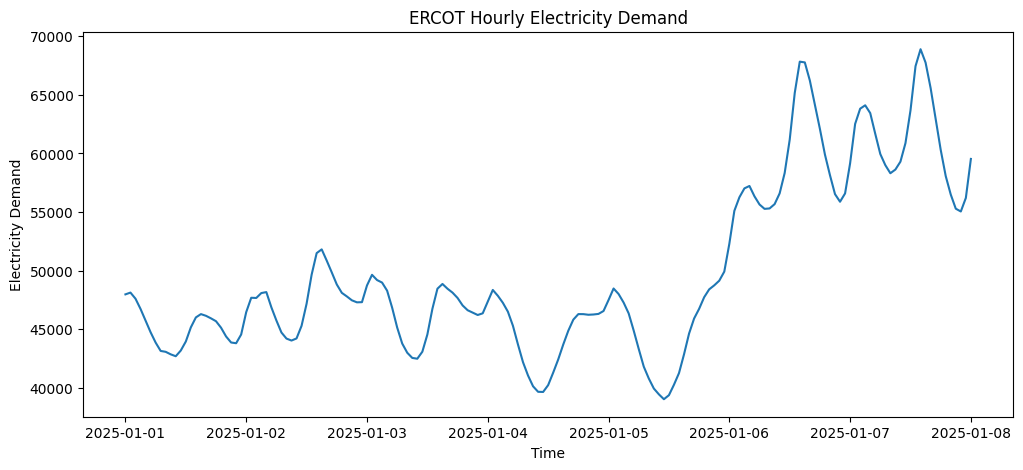

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(demand_df['timestamp'], demand_df['demand'])
plt.xlabel('Time')
plt.ylabel('Electricity Demand')
plt.title('ERCOT Hourly Electricity Demand')
plt.show()

In [29]:
demand_df.to_csv('ercos_demand.csv', index=False)

## Download the Full Historical Dataset

We extend the one-week API request to multiple years.
Because EIA API returns a limited number of rows per request,
we retrive the data in multiple pages.

In [22]:
url = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

params = {
    'api_key': EIA_API_KEY,
    'frequency': 'hourly',
    'data[0]': 'value',
    'facets[respondent][]': 'ERCO',
    'facets[type][]': 'D',
    'start': '2020-01-01T00',
    'end': '2025-12-31T23',
    'sort[0][column]': 'period',
    'sort[0][direction]': 'asc',
    'length': 5000,
    'offset': 0
}

response = requests.get(url=url, params=params)

In [23]:
json_data = response.json()

In [24]:
json_data['response'].keys()

dict_keys(['total', 'dateFormat', 'frequency', 'data', 'description'])

In [25]:
total = int(json_data['response']['total'])
total

52607

In [26]:
import math

In [27]:
page_size = 5000
num_pages = math.ceil(total / page_size)

In [28]:
historical_df = pd.DataFrame(json_data['response']['data'])

In [29]:
historical_df.shape

(5000, 7)

In [30]:
for i in range (1, num_pages):

  params ['offset'] = page_size * i

  response = requests.get(url=url, params=params)
  response.raise_for_status()

  page_data = pd.DataFrame(response.json()['response']['data'])

  historical_df = pd.concat(
      [historical_df, page_data],
      ignore_index = True
  )

In [32]:
historical_df.head()

,period,respondent,respondent-name,type,type-name,value,value-units
0,2020-01-01T00,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,40020,megawatthours
1,2020-01-01T01,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,41642,megawatthours
2,2020-01-01T02,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,40925,megawatthours
3,2020-01-01T03,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,39980,megawatthours
4,2020-01-01T04,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,39165,megawatthours


In [33]:
historical_df.to_csv(
    "ercot_historical_raw_2020_2025.csv",
    index=False
)